In [1]:
# Import libraries
import numpy as np
%pip install litstudy
import litstudy
import pickle

Note: you may need to restart the kernel to use updated packages.


In [2]:
# load the saved embedding file
docs_ai = []
#with open('HEA_Docs_ai.pkl','rb') as f:
with open('RAC_Docs_ai.pkl','rb') as f:
    docs_ai = pickle.load(f)

docs_nai = []
#with open('HEA_Docs_nai.pkl','rb') as f:
with open('RAC_Docs_nai.pkl','rb') as f:
    docs_nai = pickle.load(f)

print(docs_ai)
print(docs_nai)

<592 documents>
<9923 documents>


In [3]:
import random
# make random samples 
ai_index = list(range(0,len(docs_ai)) )
nai_index = list(range(0,len(docs_nai)) )
random.shuffle(ai_index) # shuffled 
random.shuffle(nai_index)

ai_n = int(len(docs_ai)/10)
nai_n = int(len(docs_nai)/10)

ai_index_chunks = [ai_index[i:i+ai_n] for i in range(0,len(docs_ai),ai_n)]
nai_index_chunks = [nai_index[i:i+ai_n] for i in range(0,len(docs_ai),ai_n)]

ai_index_chunks = ai_index_chunks[:-1]
nai_index_chunks = nai_index_chunks[:-1]

# split docs into 10 samples each
docs_ai_samples = [docs_ai.select(t) for t in ai_index_chunks]
docs_nai_samples = [docs_nai.select(t) for t in nai_index_chunks]

print(docs_ai_samples)
print(docs_nai_samples)

print(docs_ai_samples[0][0].title)
print(docs_nai_samples[0][0].title)


[<59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>]
[<59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>, <59 documents>]
Models for compressive strength estimation through non-destructive testing of highly self-compacting concrete containing recycled concrete aggregate and slag-based binder
Rubber concrete: Mechanical and dynamical properties


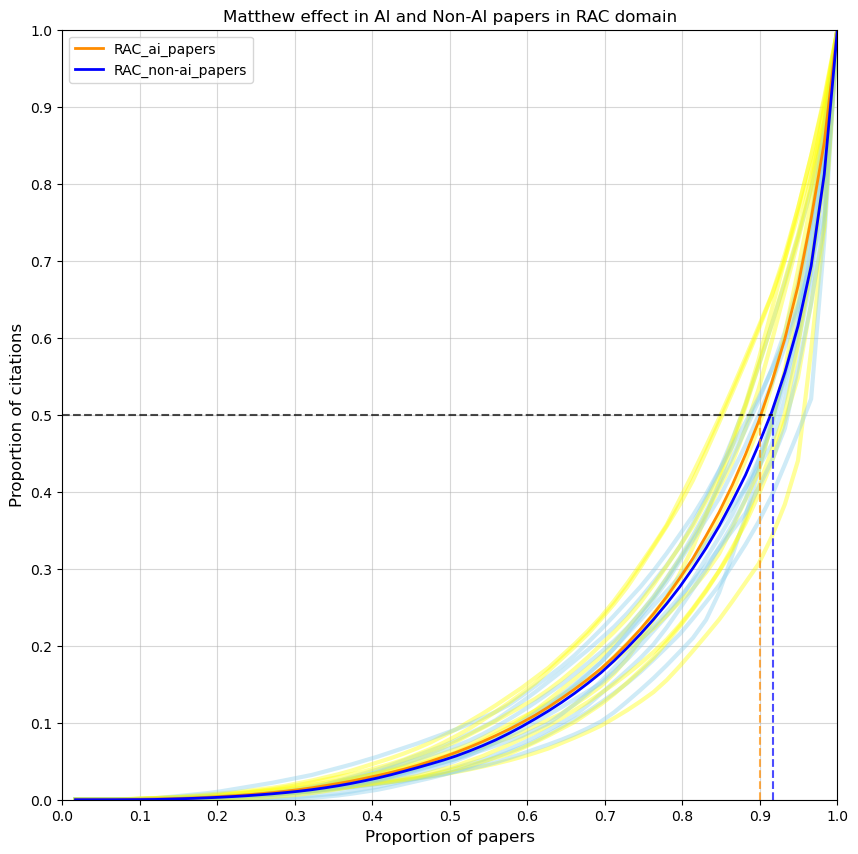

In [8]:
import matplotlib.pyplot as plt
import seaborn as sbs

def gini_plot(docs_ai_samples,docs_nai_samples):

    plt.figure(figsize=(10, 10))
    y_all_ai = []
    y_all_nai = []

    for i in range(0,10):

        docs_ai = docs_ai_samples[i]
        docs_nai = docs_nai_samples[i]

        x= []
        y_ai =[]
        y_nai =[]

        citation_ai = []
        citation_nai = []

        for item in docs_ai:
            citation_ai.append(item.citation_count)

        for item in docs_nai:
            citation_nai.append(item.citation_count)

        x = np.array( range(1,len(docs_ai)+1 ) )
        x = (lambda x: x/max(x))(x)

        y_ai = np.sort(np.array(citation_ai))
        y_nai = np.sort(np.array(citation_nai))

        sum_ai = sum(y_ai)
        sum_nai = sum(y_nai)

        y_ai = [sum(y_ai[0:i+1])/sum_ai for i in range(0,len(y_ai)) ]
        y_nai = [sum(y_nai[0:i+1])/sum_nai for i in range(0,len(y_nai)) ]

        y_all_ai.append(y_ai)
        y_all_nai.append(y_nai)

        plt.plot(x,y_ai,color='yellow',alpha=0.4,linewidth=3)
        plt.plot(x,y_nai,color='skyblue',alpha=0.4,linewidth=3)
    
    y_aver_ai = []
    y_aver_nai = []

    for j in range(0,len(docs_ai_samples[0])):
        a_ai = 0
        a_nai = 0
        for k in range(0,10):
            a_ai += y_all_ai[k][j]
            a_nai += y_all_nai[k][j]
        y_aver_ai.append(a_ai/10)
        y_aver_nai.append(a_nai/10)

    x = np.array( range(1,len(docs_ai)+1 ) )
    x = (lambda x: x/max(x))(x)

    plt.plot(x,y_aver_ai,color='darkorange',label='RAC_ai_papers',alpha=1,linewidth=2)
    plt.plot(x,y_aver_nai,color='blue',label='RAC_non-ai_papers',alpha=1,linewidth=2)

    plt.axhline(y=0.5,xmin=0,xmax=0.917,linestyle='--',color='k',alpha=0.7)
    plt.axvline(x=0.917,ymin=0,ymax=0.5,linestyle='--',color='blue',alpha=0.7)
    plt.axvline(x=0.9,ymin=0,ymax=0.5,linestyle='--',color='darkorange',alpha=0.7)

    plt.title("Matthew effect in AI and Non-AI papers in RAC domain")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.xticks(np.arange(0.0,1.1,0.1))
    plt.yticks(np.arange(0.0,1.1,0.1))
    plt.xlabel('Proportion of papers',fontsize=12)
    plt.ylabel('Proportion of citations',fontsize=12)

    plt.grid(True,alpha=0.5)
    plt.legend()
    plt.show()


gini_plot(docs_ai_samples,docs_nai_samples)

In [10]:
gini_ai_results = []
gini_nai_results = []

def gini_cal(docs_ai,docs_nai):
    citation_ai = []
    citation_nai = []

    for item in docs_ai:
        citation_ai.append(item.citation_count)

    for item in docs_nai:
        citation_nai.append(item.citation_count)

    x_ai = np.array( range(1,len(docs_ai)+1 ) )
    x_nai = np.array( range(1,len(docs_nai)+1) )

    y_ai = np.sort(np.array(citation_ai))
    y_nai = np.sort(np.array(citation_nai))

    size_ai = len(docs_ai)
    size_nai = len(docs_nai)

    gini_ai = ( 2*np.sum(np.multiply(x_ai,y_ai)) )/(size_ai*np.sum(y_ai)) - (size_ai+1)/size_ai
    gini_nai = ( 2*np.sum(np.multiply(x_nai,y_nai)) )/(size_nai*np.sum(y_nai)) - (size_nai+1)/size_nai

    print(gini_ai,":Gini Coefficient for RAC ai papers")
    print(gini_nai, ":Gini Coefficient for RAC non-ai papers")

    gini_ai_results.append(gini_ai)
    gini_nai_results.append(gini_nai)

for i in range(0,10):
    gini_cal(docs_ai_samples[i],docs_nai_samples[i])


0.7859414252551913 :Gini Coefficient for RAC ai papers
0.6372122261626598 :Gini Coefficient for RAC non-ai papers
0.5945118118335486 :Gini Coefficient for RAC ai papers
0.7642153591152117 :Gini Coefficient for RAC non-ai papers
0.6692563312747524 :Gini Coefficient for RAC ai papers
0.7466474789468074 :Gini Coefficient for RAC non-ai papers
0.6364088621507491 :Gini Coefficient for RAC ai papers
0.7097501673772861 :Gini Coefficient for RAC non-ai papers
0.6941355618233291 :Gini Coefficient for RAC ai papers
0.7228645190257044 :Gini Coefficient for RAC non-ai papers
0.6611382621052997 :Gini Coefficient for RAC ai papers
0.6597621940289591 :Gini Coefficient for RAC non-ai papers
0.678414590847084 :Gini Coefficient for RAC ai papers
0.6368818924797119 :Gini Coefficient for RAC non-ai papers
0.7376040891410276 :Gini Coefficient for RAC ai papers
0.6972578200358275 :Gini Coefficient for RAC non-ai papers
0.7384387965933716 :Gini Coefficient for RAC ai papers
0.6775987067698639 :Gini Coefficie

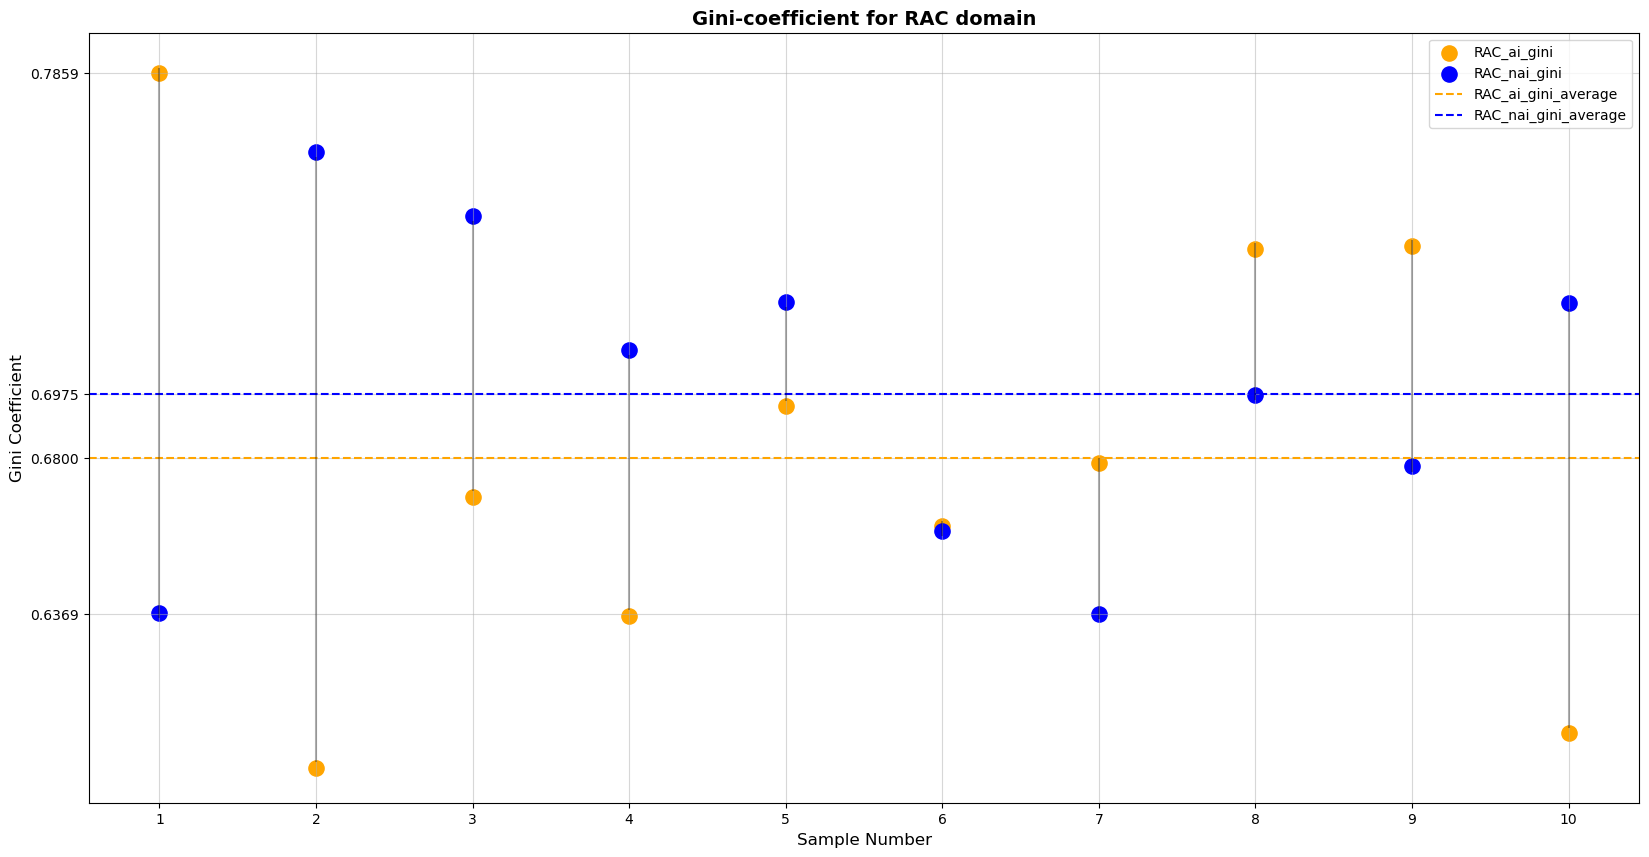

In [13]:
x = np.arange(1,11,1)
aver_ai = np.average(gini_ai_results)
aver_nai = np.average(gini_nai_results)
#median_ai = np.median(gini_ai_results)
#median_nai = np.median(gini_nai_results)
#print(median_ai)
#print(median_nai)
#print(aver_ai)
#print(aver_nai)

plt.figure(figsize=(20, 10))
plt.scatter(x,gini_ai_results,label='RAC_ai_gini',s=120,alpha=1,color='orange')
plt.scatter(x,gini_nai_results,label='RAC_nai_gini',s=120,alpha=1,color='blue')
plt.axhline(y=aver_ai,label='RAC_ai_gini_average',linestyle='--',color='orange')
#plt.axhline(y=median_ai,label='HEA_ai_gini_median',linestyle='-',color='orange')
plt.axhline(y=aver_nai,label='RAC_nai_gini_average',linestyle='--',color='blue')
#plt.axhline(y=median_nai,label='HEA_ai_gini_median',linestyle='-',color='blue')

min_e = np.subtract(gini_ai_results,-0.0015)
max_e = np.subtract(gini_nai_results,0.0015)
plt.vlines(x,ymin=min_e,ymax=max_e,colors='k',alpha=0.3)
plt.grid(True,alpha=0.5)

plt.xticks(x)
plt.yticks([min(gini_nai_results),aver_nai,aver_ai,max(gini_ai_results)])
plt.xlabel('Sample Number',fontsize=12)
plt.ylabel('Gini Coefficient',fontsize=12)
plt.title('Gini-coefficient for RAC domain', fontsize=14, fontweight='bold')

plt.legend()
plt.show()

In [ ]:
# testing for citation metadata extract --- failed!!!
max_citation_ai = max(y_ai)
print(max_citation_ai, ": number of max citation in ai papers") 
top_ai = docs_ai.filter_docs(lambda d: d. citation_count == max_citation_ai)
print(top_ai[0].citations, ": list of documents that cite this document")
print(top_ai[0].title, ": title ")
print(top_ai[0].publication_year, ": publication year")

max_citation_nai = max(y_nai)
print(max_citation_nai, ": number of max citation in non-ai papers") 
top_nai = docs_nai.filter_docs(lambda d: d. citation_count == max_citation_nai)
print(top_nai[0].citations, ": list of documents that cite this document")
print(top_nai[0].title, ": title ")
print(top_nai[0].publication_year, ": publication year")

766 : number of max citation in ai papers
None : list of documents that cite this document
Fatigue behavior of Al 0.5CoCrCuFeNi high entropy alloys : title 
2012 : publication year
7718 : number of max citation in non-ai papers
None : list of documents that cite this document
A critical review of high entropy alloys and related concepts : title 
2017 : publication year


In [31]:
x = np.array([1,2,3,4,5])
y = np.array([1,1,1,2,15])
gini = ( 2*np.sum(np.multiply(x,y)) )/(5*np.sum(y)) - 6/5
print(gini,":test")

0.5800000000000001 :test
